In [18]:
from setupimp import  RUN_FULL_MODEL
import pandas

import sys
from pathlib import Path

sys.path.append(str(Path.cwd() / "Dev" / "07_Orbit_Correction"))

from orbit_correction import bpm_measurements_from_twiss, plot_orbit_with_bpm, normalise_bpm_measurements




nominal_0ms
<class 'optics_gui.snapshot.SnapshotConfig'>
<class 'optics_gui.snapshot.SnapshotConfig'>
True
<class 'optics_gui.snapshot.SnapshotConfig'>
True
optics_gui.snapshot
optics_gui.snapshot


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,keyword,s,x,y,px,py,x_mm,y_mm,orbit_radius_m,orbit_radius_mm
#s,synchrotron$start:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_datum,sp0_datum:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr8,sp0_dipfr8:1,sbend,0.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr9,sp0_dipfr9:1,sbend,0.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr10,sp0_dipfr10:1,sbend,0.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


nominal_orbit_snapshot: SnapshotResult(config=SnapshotConfig(cycle_time_ms=0.0, label='student nominal orbit', case='nominal', snapshot_id='student_nominal_orbit', lattice_folder='c:\\Users\\Visitor\\Desktop\\Orbittest\\optics_gui_wx26_test\\Dev\\Lattice_Files\\00_Simplified_Lattice', sequence_name='synchrotron', output_dir='c:\\Users\\Visitor\\Desktop\\Orbittest\\optics_gui_wx26_test\\Dev\\12_IO\\student_runs\\orbit', aperture_file='ISIS.aperture', main_magnet_mode='rcs_bare', requested_qx=4.31, requested_qy=3.83, base_qx=4.31, base_qy=3.83, tune_method='di_wright', harmonics={}, error_table_paths=[], error_table_name='error_table', hd_corrector_kicks_rad=None, vd_corrector_kicks_rad=None, hd_corrector_currents_A=None, vd_corrector_currents_A=None, corrector_prefer='kicks', corrector_settings=None, run_envelope=False, envelope_inputs=EnvelopeInputs(emit_x_pi_mm_mrad=300.0, emit_y_pi_mm_mrad=300.0, emittance_mode='geometric', sigma_scale=3.0, dp_over_p=0.002, label='envelope', metadata

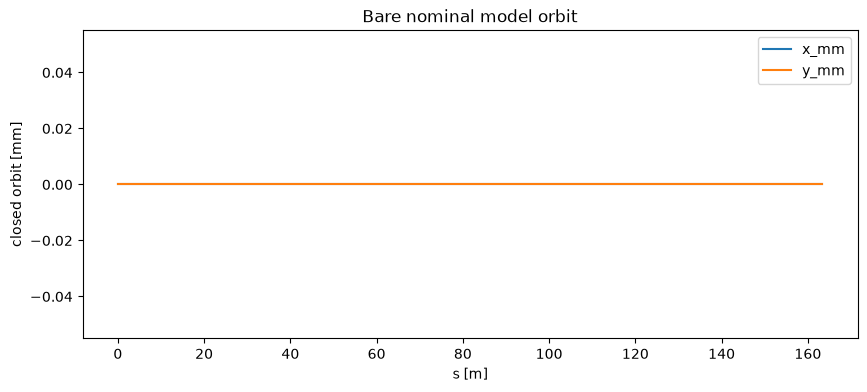

In [19]:
import nbimporter
import nbformat
from pathlib import Path

# Read and execute the notebook to get the snapshot
nb_path = Path("Nominal_error_corr_orbit.ipynb")
with open(nb_path) as f:
    nb = nbformat.read(f, as_version=4)

# Extract and execute code cells
for cell in nb.cells:
    if cell.cell_type == "code":
        exec(cell.source, globals())

# Now we have nominal_orbit_snapshot available
print(f"nominal_orbit_snapshot: {nominal_orbit_snapshot}")

In [13]:
pip install nbimporter

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Example measured orbit table using real BPM-style names and known s positions.
# The earlier dummy names produced NaN s/error columns because those optional columns were not supplied.
# The backend can resolve BPM labels against TWISS names with resolve_bpm_to_twiss_name(...),
# and bpm_measurements_from_twiss(...) is the safest way to get real names and s positions from a model table.
if RUN_FULL_MODEL:
    measured_bpm_table = bpm_measurements_from_twiss(nominal_orbit_snapshot.table("twiss"), plane="H").head(8)
    measured_bpm_table = measured_bpm_table.copy()
    measured_bpm_table["closed_orbit_mm"] = [0.8, -0.6, 1.1, -0.9, 0.4, -0.3, 0.7, -0.5]
else:
    raw_measured_orbit = pd.DataFrame(
        [
            {"bpm": "sp0_r0hm1", "plane": "H", "closed_orbit_mm": 0.8, "closed_orbit_mm_err": 0.1, "s": 0.730500, "enabled": True},
            {"bpm": "sp0_r0hm2", "plane": "H", "closed_orbit_mm": -0.6, "closed_orbit_mm_err": 0.1, "s": 5.971000, "enabled": True},
            {"bpm": "sp1_r1hm1", "plane": "H", "closed_orbit_mm": 1.1, "closed_orbit_mm_err": 0.1, "s": 22.285282, "enabled": True},
            {"bpm": "sp1_r1hm2", "plane": "H", "closed_orbit_mm": -0.9, "closed_orbit_mm_err": 0.1, "s": 24.416282, "enabled": True},
        ]
    )
    measured_bpm_table = normalise_bpm_measurements(raw_measured_orbit)

measured_bpm_table


,bpm,plane,closed_orbit_mm,closed_orbit_mm_err,s,enabled
0,sp0_r0hm1,H,0.8,0.1,0.730500,True
1,sp0_r0hm2,H,-0.6,0.1,5.971000,True
2,sp1_r1hm1,H,1.1,0.1,22.285282,True
3,sp1_r1hm2,H,-0.9,0.1,24.416282,True
4,sp2_r2hm1,H,0.4,0.1,33.403064,True
5,sp2_r2hm2,H,-0.3,0.1,38.643564,True
6,sp3_r3hm1,H,0.7,0.1,54.979846,True
7,sp4_r4hm2,H,-0.5,0.1,71.316128,True


In [20]:
# Create error orbit snapshot with jan26 error table applied
if RUN_FULL_MODEL:
    jan26_error_table = repo_root / "Dev" / "Error_Tables" / "jan26_survey_corrected.tfs"
    
    error_orbit_config = copy_snapshot_config(
        orbit_base_config,
        snapshot_id="jan26_error_orbit",
        label="jan26 error orbit",
        error_table_paths=[str(jan26_error_table)],
        orbit_correction_configs=[],
    )
    
    error_orbit_snapshot = build_machine_snapshot(error_orbit_config)
    print(f"Created error_orbit_snapshot with error table: {jan26_error_table.name}")
else:
    print("error_orbit_snapshot creation skipped because RUN_FULL_MODEL is False.")

Created error_orbit_snapshot with error table: jan26_survey_corrected.tfs


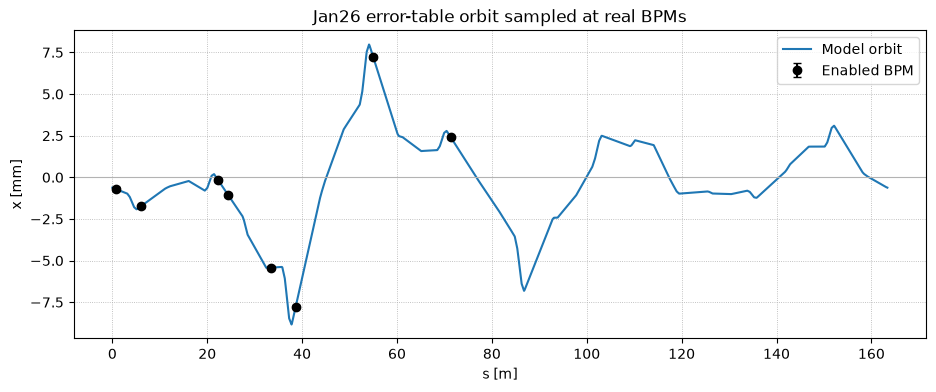

In [21]:
if RUN_FULL_MODEL:
    jan26_bpm_match = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="H").head(8)
    ax = plot_orbit_with_bpm(
        error_orbit_snapshot.table("twiss"),
        jan26_bpm_match,
        plane="H",
        title="Jan26 error-table orbit sampled at real BPMs",
    )
else:
    jan26_bpm_match = measured_bpm_table.copy()
    print("Jan26 BPM sampling plot skipped because RUN_FULL_MODEL is False.")